In [ ]:
import numpy as np
from sklearn.preprocessing import normalize
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))
from utils.utils import load_model

SAVE_DIR = "../models"

MODEL_CONFIGS = [
    ("clip_H_14",    "clip_H_14.npy",         "labels.npy"),
    ("clip_L_14",    "clip_L_14.npy", "labels.npy"),
    ("dino",         "dino.npy",     "labels.npy"),
    ("multi_model_1","multi_model_1.npy",      "labels.npy"),
    ("multi_model_2","multi_model_2.npy",      "labels.npy"),
    ("resnet50_features.npy",    "resnet50_features.npy",   "resnet50_labels.npy"),
    ("efficientnet", "efficientnet.npy", "efficientnet_labels.npy"),
    ("efficientnet_b7", "efficientnet_b7.npy", "efficientnet_b7_labels.npy"),
]

model_data = {}
for model_name, feat_file, label_file in MODEL_CONFIGS:
    model_data[model_name] = load_model(SAVE_DIR, feat_file, label_file)
    print(f"Loaded {model_name}: {model_data[model_name][0].shape}")

Loaded clip_H_14: (10980, 1024)
Loaded clip_L_14: (10980, 768)
Loaded dino: (10980, 384)
Loaded multi_model_1: (10980, 1152)
Loaded multi_model_2: (10980, 256)
Loaded resnet50_features.npy: (10980, 2048)
Loaded efficientnet: (10980, 5504)
Loaded efficientnet_b7: (10980, 2560)


In [7]:
# ── kNN graph (mutual + weighted) ──────────────────────
from sklearn.neighbors import NearestNeighbors

def build_knn_graph(features, k=40):
    nn = NearestNeighbors(n_neighbors=k+1, metric='cosine', n_jobs=-1)
    nn.fit(features)
    distances, indices = nn.kneighbors(features)

    neighbor_sets = [set(row[1:]) for row in indices]

    edges = {}
    for i in range(len(features)):
        for d, j in zip(distances[i][1:], indices[i][1:]):
            if i in neighbor_sets[j]:  # mutual kNN
                sim = 1 - d
                if sim > 0.1:
                    key = (min(i, int(j)), max(i, int(j)))
                    edges[key] = sim
    edge_list = list(edges.keys())
    weights   = list(edges.values())
    return distances, indices, edge_list, weights

# ── Build graphs for all models ───────────────────────
graph_data = {} 
for model_name, (features, _, _) in model_data.items():
    graph_data[model_name] = build_knn_graph(features, k=40)
    print(f"{model_name}: {len(graph_data[model_name][2])} edges")

clip_H_14: 98695 edges
clip_L_14: 102367 edges
dino: 126700 edges
multi_model_1: 138440 edges
multi_model_2: 170988 edges
resnet50_features.npy: 112016 edges
efficientnet: 133320 edges
efficientnet_b7: 130055 edges


In [8]:
# ── Build graph + kNN smoothing ────────────────────────
import igraph as ig

def build_igraph(features, edge_list, weights):
    g = ig.Graph(n=len(features), edges=edge_list, directed=False)
    g.es['weight'] = weights
    print(f"Nodes: {g.vcount()}, Edges: {g.ecount()}")
    return g

def knn_smoothing(features, indices, alpha=0.5):
    new_feat = features.copy()
    for i in range(len(features)):
        neigh = indices[i][1:]
        new_feat[i] = (1 - alpha) * features[i] + alpha * features[neigh].mean(axis=0)
    return normalize(new_feat)

# ── Build igraph objects and smooth features ───────────
igraph_data   = {} 
smoothed_data = {}  
for model_name, (features, labels, labels_single) in model_data.items():
    distances, indices, edge_list, weights = graph_data[model_name]
    g = build_igraph(features, edge_list, weights)
    igraph_data[model_name]   = g
    smoothed_data[model_name] = knn_smoothing(features, indices, alpha=0.5)

Nodes: 10980, Edges: 98695
Nodes: 10980, Edges: 102367
Nodes: 10980, Edges: 126700
Nodes: 10980, Edges: 138440
Nodes: 10980, Edges: 170988
Nodes: 10980, Edges: 112016
Nodes: 10980, Edges: 133320
Nodes: 10980, Edges: 130055


In [ ]:
# ── Leiden scan ───────────────────────────────────────
import leidenalg
from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_rand_score,
    homogeneity_score
)
from collections import Counter
RESOLUTIONS = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
def purity_score(y_true, y_pred):
    total = 0
    for c in np.unique(y_pred):
        idx    = np.where(y_pred == c)[0]
        labels = y_true[idx]
        total += Counter(labels).most_common(1)[0][1]
    return total / len(y_true)

def leiden_scan(g, labels_single, resolutions=RESOLUTIONS, model_name=""):
    print(f"\n=== Leiden Scan: {model_name} ===")
    results = []
    for res in resolutions:
        partition = leidenalg.find_partition(
            g,
            leidenalg.RBConfigurationVertexPartition,
            weights='weight',
            resolution_parameter=res,
            seed=42,
        )
        cluster_labels = np.array(partition.membership)
        nmi    = normalized_mutual_info_score(labels_single, cluster_labels)
        ari    = adjusted_rand_score(labels_single, cluster_labels)
        homo   = homogeneity_score(labels_single, cluster_labels)
        purity = purity_score(labels_single, cluster_labels)
        n_clusters = len(set(cluster_labels))
        print(
            f"res={res:>2} | clusters={n_clusters:<4} "
            f"| NMI={nmi:.4f} | ARI={ari:.4f} | H={homo:.4f} | P={purity:.4f}"
        )
        results.append(dict(
            model=model_name, res=res, n_clusters=n_clusters,
            nmi=nmi, ari=ari, homo=homo, purity=purity,
            cluster_labels=cluster_labels,
        ))
    return results

# ── Run Leiden scan across all models ─────────────────
all_leiden_results = {}  # name -> list of result dicts
for model_name, (features, labels, labels_single) in model_data.items():
    g = igraph_data[model_name]
    all_leiden_results[model_name] = leiden_scan(g, labels_single, model_name=model_name)


=== Leiden Scan: clip_H_14 ===
res= 5 | clusters=214  | NMI=0.5588 | ARI=0.0911 | H=0.4732 | P=0.1771
res=10 | clusters=267  | NMI=0.6019 | ARI=0.1253 | H=0.5343 | P=0.2250
res=20 | clusters=356  | NMI=0.6413 | ARI=0.1532 | H=0.5967 | P=0.2756
res=30 | clusters=446  | NMI=0.6682 | ARI=0.1795 | H=0.6399 | P=0.3161
res=40 | clusters=523  | NMI=0.6839 | ARI=0.1910 | H=0.6675 | P=0.3453
res=50 | clusters=605  | NMI=0.6975 | ARI=0.1981 | H=0.6916 | P=0.3699
res=60 | clusters=678  | NMI=0.7056 | ARI=0.1981 | H=0.7077 | P=0.3841
res=70 | clusters=748  | NMI=0.7134 | ARI=0.2040 | H=0.7221 | P=0.4026
res=80 | clusters=809  | NMI=0.7187 | ARI=0.1999 | H=0.7323 | P=0.4133

=== Leiden Scan: clip_L_14 ===
res= 5 | clusters=317  | NMI=0.5949 | ARI=0.1017 | H=0.5066 | P=0.2133
res=10 | clusters=379  | NMI=0.6442 | ARI=0.1473 | H=0.5794 | P=0.2713
res=20 | clusters=463  | NMI=0.6793 | ARI=0.1854 | H=0.6370 | P=0.3202
res=30 | clusters=517  | NMI=0.6936 | ARI=0.2042 | H=0.6632 | P=0.3454
res=40 | clus

In [11]:
from collections import Counter
import matplotlib.pyplot as plt

# ── Top-10 label purity per model ─────────────────────
for model_name, results in all_leiden_results.items():
    last_result    = results[-1]
    cluster_labels = last_result['cluster_labels']
    _, labels, _   = model_data[model_name]
    _, _, labels_flat = model_data[model_name]

    top_labels = [l for l, _ in Counter(labels_flat).most_common(10)]
    print(f"\nTop 10 labels [{model_name}]:")
    for l in top_labels:
        mask_l            = labels_flat == l
        pred_for_l        = cluster_labels[mask_l]
        n_unique          = len(set(pred_for_l))
        most_common_cluster = Counter(pred_for_l).most_common(1)[0]
        purity            = most_common_cluster[1] / mask_l.sum()
        print(f"  Label {l}: {mask_l.sum()} img → {n_unique} clusters | purity={purity:.2f}")


Top 10 labels [clip_H_14]:
  Label 60: 94 img → 24 clusters | purity=0.13
  Label 409: 93 img → 37 clusters | purity=0.19
  Label 418: 91 img → 19 clusters | purity=0.33
  Label 550: 84 img → 20 clusters | purity=0.27
  Label 618: 82 img → 25 clusters | purity=0.27
  Label 703: 82 img → 36 clusters | purity=0.18
  Label 189: 81 img → 30 clusters | purity=0.25
  Label 909: 80 img → 33 clusters | purity=0.19
  Label 601: 74 img → 37 clusters | purity=0.14
  Label 868: 74 img → 44 clusters | purity=0.09

Top 10 labels [clip_L_14]:
  Label 60: 94 img → 19 clusters | purity=0.18
  Label 409: 93 img → 34 clusters | purity=0.16
  Label 418: 91 img → 14 clusters | purity=0.29
  Label 550: 84 img → 14 clusters | purity=0.26
  Label 618: 82 img → 25 clusters | purity=0.50
  Label 703: 82 img → 22 clusters | purity=0.22
  Label 189: 81 img → 23 clusters | purity=0.22
  Label 909: 80 img → 22 clusters | purity=0.21
  Label 601: 74 img → 28 clusters | purity=0.14
  Label 868: 74 img → 32 clusters 

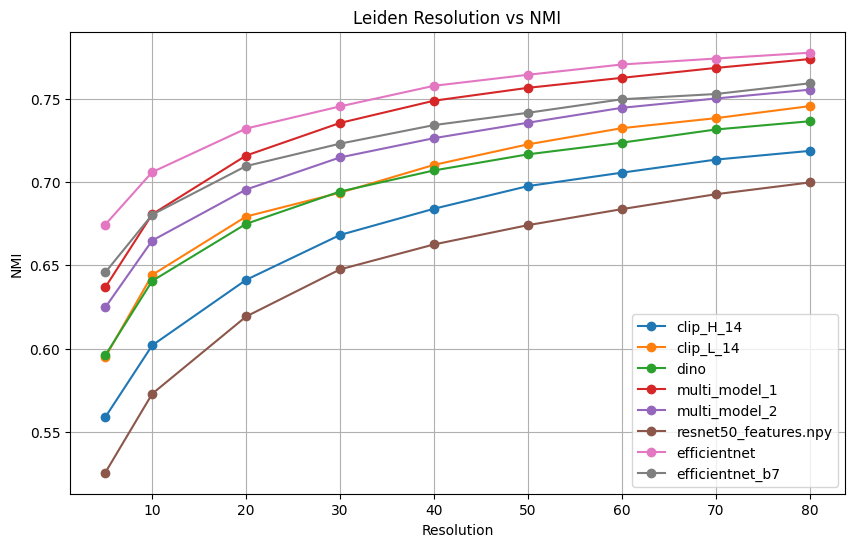

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for model_name, results in all_leiden_results.items():
    x = [r["res"] for r in results]
    y = [r["nmi"] for r in results]

    plt.plot(x, y, marker="o", label=model_name)

plt.xlabel("Resolution")
plt.ylabel("NMI")
plt.title("Leiden Resolution vs NMI")
plt.legend()
plt.grid(True)
plt.show()

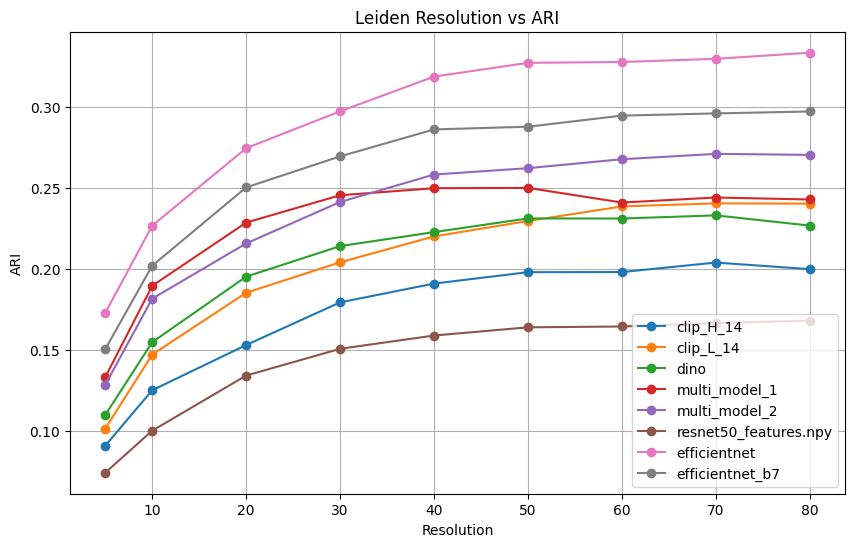

In [15]:
plt.figure(figsize=(10,6))

for model_name, results in all_leiden_results.items():
    x = [r["res"] for r in results]
    y = [r["ari"] for r in results]

    plt.plot(x, y, marker="o", label=model_name)

plt.xlabel("Resolution")
plt.ylabel("ARI")
plt.title("Leiden Resolution vs ARI")
plt.legend()
plt.grid(True)
plt.show()

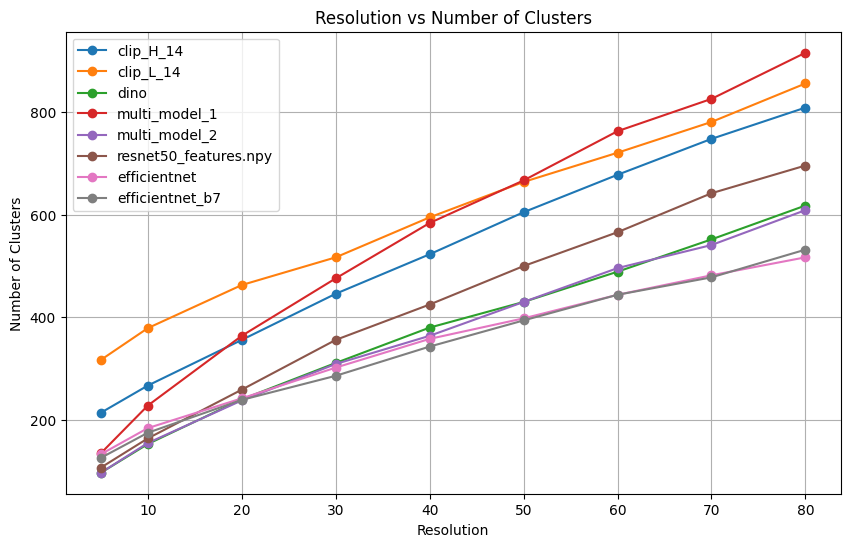

In [16]:
plt.figure(figsize=(10,6))

for model_name, results in all_leiden_results.items():
    x = [r["res"] for r in results]
    y = [r["n_clusters"] for r in results]

    plt.plot(x, y, marker="o", label=model_name)

plt.xlabel("Resolution")
plt.ylabel("Number of Clusters")
plt.title("Resolution vs Number of Clusters")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
best_rows = []

for model_name, results in all_leiden_results.items():

    best = max(results, key=lambda x: x["nmi"])

    best_rows.append({
        "model": model_name,
        "nmi": best["nmi"],
        "ari": best["ari"],
        "purity": best["purity"],
        "homo": best["homo"],
        "res": best["res"]
    })

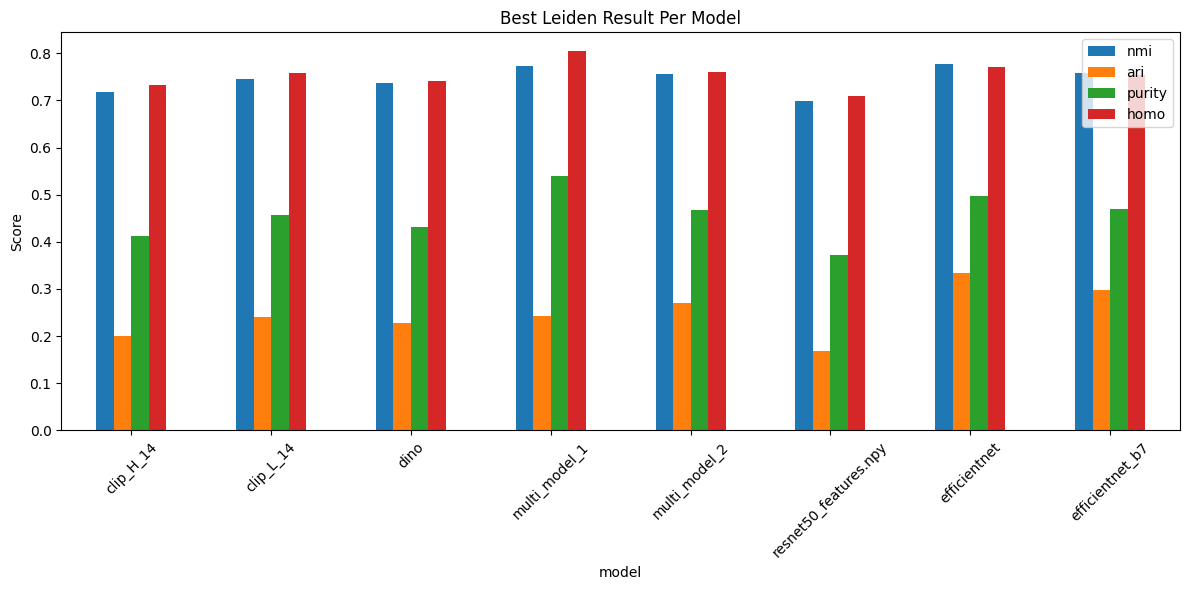

In [18]:
import pandas as pd

df = pd.DataFrame(best_rows)

df.plot(
    x="model",
    y=["nmi","ari","purity","homo"],
    kind="bar",
    figsize=(12,6)
)

plt.title("Best Leiden Result Per Model")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()